# BioLM Pipeline Demo

End-to-end walkthrough of the BioLM pipeline SDK hitting the **live API**.

Covers:
- **DataPipeline** — multi-model predictions and filters
- **Interactive exploration** — `summary()`, `explore()`, `stats()`, `query()`
- **`plot()`** — funnel, distributions, scatter, diversity
- **Resume** — zero API calls on cached data
- **Clustering** — ESM2 embeddings + K-means + PCA visualization
- **Diversity sampling** — select maximally diverse representatives
- **Export** — CSV, Parquet

**Requirements:**
```bash
pip install biolmai[pipeline]  # includes duckdb, numpy, pandas, scikit-learn
pip install matplotlib         # for plots
export BIOLMAI_TOKEN=your-token-here
```
Get a token at https://biolm.ai/ui/accounts/user-api-tokens/

## 0 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 110

from biolmai.pipeline import (
    DataPipeline,
    DuckDBDataStore,
    EmbeddingSpec,
    ExtractionSpec,
    DiversitySamplingFilter,
    RankingFilter,
    ThresholdFilter,
    ValidAminoAcidFilter,
)

TOKEN = os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    print("ERROR: Set BIOLMAI_TOKEN before running this notebook.")
    print("  Get one at https://biolm.ai/ui/accounts/user-api-tokens/")
    sys.exit(1)

OUTPUT_DIR = Path("outputs/notebook_demo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: outputs/notebook_demo


## 1 — Peptide set

30 antimicrobial peptides (AMPs) of varying length, charge, and hydrophobicity.

In [2]:
PEPTIDES = [
    # Magainins / frog-derived
    "GIGKFLHSAKKFGKAFVGEIMNS",        # Magainin 2
    "GIGKFLHSAGKFGKAFVGEIMKS",        # Magainin 1 analog
    "GLFDIIKKIAESF",                   # Aurein 1.2
    "GLFDIVKKVVGALGSL",               # Aurein 2.2
    "FLPLILRKIVTAL",                   # Citropin 1.1
    # Human defensins / cathelicidins
    "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",  # LL-37
    "RLFDKIRQVIRKF",                   # Indolicidin analog
    "KWKLFKKIPKFLHLAKKF",             # Cecropin-melittin hybrid
    "DHYNCVSSGGQCLYSACPIFTKIQGTCYRGKAKCCK",  # HNP-1 analog
    # Insect-derived
    "RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK",  # Cecropin A
    "KWKLFKKIEKVGQNIRDGIIKAGPAVAVVGQATQIAK",  # Cecropin B
    "GIGAVLKVLTTGLPALISWIKRKRQQ",     # Melittin
    "VDKGSYLPRPTPPRPIYNRN",           # Apidaecin
    "GKPRPYSPRPTSHPRPIRV",            # Drosocin
    # Synthetic / designed
    "KLAKLAKKLAKLAK",                  # (KLA)3
    "LKLLKKLLKLLKKL",                  # Designed AMP
    "RRWWRRWWRR",                      # Synthetic arginine-rich
    "KWKWKWKWKW",                      # KW repeat
    "GIKKFLGSIWKFIKAFVKEIMN",         # MSI-78 (pexiganan)
    # Cyclic / constrained
    "RRLCRIVVIRVCR",                   # Tachyplesin analog
    # Short peptides
    "RRWQWR",                          # Lactoferricin fragment
    "RWRWRW",                          # RW repeat
    "FKRIVQRIKDFL",                    # LL-37 fragment
    "KFLKKAKKFGK",                     # Magainin fragment
    "GIGKFLHSAK",                      # Magainin N-term
    "KWKLFKKI",                        # Short cecropin
    "RLFDKIRQ",                        # Indolicidin short
    # Longer peptides
    "GLFDIIKKIAESFLPKV",              # Aurein extended
    "GIGKFLHSAKKFGKAFV",              # Magainin 2 fragment
    "KWKLFKKIPKFLHLAK",               # Cecropin fragment
]

print(f"{len(PEPTIDES)} peptides")
print(f"Length range: {min(len(s) for s in PEPTIDES)}-{max(len(s) for s in PEPTIDES)} aa")

30 peptides
Length range: 6-37 aa


## 2 — Multi-model predictions + filtering

Predict melting temperature (Tm) and solubility in parallel, then filter.

In [3]:
db_path = OUTPUT_DIR / "pipeline.duckdb"
ds = DuckDBDataStore(db_path)

pipeline = DataPipeline(
    sequences=PEPTIDES,
    datastore=ds,
    run_id="demo_v1",
    output_dir=str(OUTPUT_DIR),
    verbose=True,
)

# Validate amino acids first
pipeline.add_filter(
    ValidAminoAcidFilter(verbose=True),
    stage_name="validate",
)

# Parallel predictions (both depend only on validate)
pipeline.add_prediction(
    "temberture-regression",
    action="predict",
    extractions="prediction",
    columns="melting_temperature",
    stage_name="predict_tm",
    depends_on=["validate"],
    batch_size=16,
)
pipeline.add_prediction(
    "soluprot",
    action="predict",
    extractions="soluble",
    columns="solubility",
    stage_name="predict_sol",
    depends_on=["validate"],
    batch_size=16,
)

# Sequential filters
pipeline.add_filter(
    ThresholdFilter("melting_temperature", min_value=40.0),
    stage_name="filter_tm",
    depends_on=["predict_tm", "predict_sol"],
)
pipeline.add_filter(
    RankingFilter("solubility", n=15, ascending=False),
    stage_name="filter_sol_top15",
)

stage_results = pipeline.run()

df = pipeline.get_final_data()
print(f"\nInput: {len(PEPTIDES)} peptides")
print(f"Output: {len(df)} peptides after filters")
df.head()

Added stage: FilterStage('validate')
Added stage: PredictionStage('predict_tm', depends_on=['validate'])
Added stage: PredictionStage('predict_sol', depends_on=['validate'])
Added stage: FilterStage('filter_tm', depends_on=['predict_tm', 'predict_sol'])
Added stage: FilterStage('filter_sol_top15', depends_on=['filter_tm'])



############################################################
# Pipeline: DataPipeline
# Run ID: demo_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: predict_tm, predict_sol (parallel)
  Level 3: filter_tm
  Level 4: filter_sol_top15

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30



StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Executing 2 stages in parallel...

Stage: predict_tm
Input: 30 sequences
Depends on: validate
  Cached: 0/30
  To compute: 30
  Calling temberture-regression.predict...


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_70843/3538430155.py:49: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  stage_results = pipeline.run()


  temberture-regression:   0%|          | 0/2 [00:00<?, ?batch/s]


Stage: predict_sol
Input: 30 sequences
Depends on: validate
  Cached: 0/30
  To compute: 30
  Calling soluprot.predict...


  soluprot:   0%|          | 0/2 [00:00<?, ?batch/s]

  Completed: 30 sequences in 2 batches (max 5 concurrent)

StageResult(predict_tm: in=30, out=30, cached=0, computed=30, filtered=0, time=9.8s)


  Completed: 30 sequences in 2 batches (max 5 concurrent)

StageResult(predict_sol: in=30, out=9, cached=0, computed=30, filtered=21, time=14.1s)

Stage: filter_tm
Input: 30 sequences
Depends on: predict_tm, predict_sol
  Applying filter: ThresholdFilter(column='melting_temperature', min=40.0)
  Filtered out: 0/30
  Remaining: 30

StageResult(filter_tm: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Stage: filter_sol_top15
Input: 30 sequences
Depends on: filter_tm
  Applying filter: RankingFilter(column='solubility', n=15, method='top')
  Filtered out: 21/30
  Remaining: 9

StageResult(filter_sol_top15: in=30, out=9, cached=0, computed=0, filtered=21, time=0.0s)

############################################################
# Pipeline completed in 14.4s
# Final sequences: 9
############################################################


Input: 30 peptides
Output: 9 peptides after filters


,sequence_id,sequence,length,hash,melting_temperature,solubility
0,10,RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK,37,b5a5fee6e6202479,69.676895,0.4491
1,13,VDKGSYLPRPTPPRPIYNRN,20,bd0ecacc7387f2b8,56.023178,0.9639
2,19,GIKKFLGSIWKFIKAFVKEIMN,22,5487bb3a746b888a,78.899384,0.2126
3,2,GIGKFLHSAGKFGKAFVGEIMKS,23,2272bcf58012e271,62.593925,0.2674
4,6,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,37,2812049e6fed6cf1,73.924812,0.8687


## 3 — Interactive exploration

Rich introspection methods built into the pipeline object.

In [4]:
# summary() — per-stage input/output/cached/computed counts
pipeline.summary()

,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,predict_tm,30,30,0,0,30,9.8
2,predict_sol,30,9,21,0,30,14.1
3,filter_tm,30,30,0,0,0,0.0
4,filter_sol_top15,30,9,21,0,0,0.0


In [5]:
# explore() — high-level datastore stats
pipeline.explore()

{'sequences': 30,
 'embeddings': 0,
 'generated': 0,
 'completed_stages': 5,
 'predictions': {'melting_temperature': 30, 'solubility': 9}}

In [6]:
# stats() — stage completion records from DuckDB
pipeline.stats()

,stage_name,status,input_count,output_count,completed_at
0,validate,completed,30,30,2026-03-13 20:33:35.467175
1,predict_tm,completed,30,30,2026-03-13 20:33:45.286249
2,predict_sol,completed,30,9,2026-03-13 20:33:49.728148
3,filter_tm,completed,30,30,2026-03-13 20:33:49.752046
4,filter_sol_top15,completed,30,9,2026-03-13 20:33:49.770175


In [7]:
# query() — arbitrary SQL on the pipeline's DuckDB
pipeline.query("""
    SELECT
        s.sequence,
        s.length,
        tm.value AS melting_temperature,
        sol.value AS solubility
    FROM sequences s
    JOIN predictions tm ON s.sequence_id = tm.sequence_id
        AND tm.prediction_type = 'melting_temperature'
    JOIN predictions sol ON s.sequence_id = sol.sequence_id
        AND sol.prediction_type = 'solubility'
    ORDER BY tm.value DESC
    LIMIT 10
""")

,sequence,length,melting_temperature,solubility
0,GIKKFLGSIWKFIKAFVKEIMN,22,78.899384,0.2126
1,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,37,73.924812,0.8687
2,RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK,37,69.676895,0.4491
3,KWKLFKKIEKVGQNIRDGIIKAGPAVAVVGQATQIAK,37,63.816177,0.4992
4,GIGKFLHSAGKFGKAFVGEIMKS,23,62.593925,0.2674
5,GIGKFLHSAKKFGKAFVGEIMNS,23,62.520573,0.2963
6,DHYNCVSSGGQCLYSACPIFTKIQGTCYRGKAKCCK,36,56.134567,0.9601
7,VDKGSYLPRPTPPRPIYNRN,20,56.023178,0.9639
8,GIGAVLKVLTTGLPALISWIKRKRQQ,26,51.632015,0.8815


## 4 — Plots

`pipeline.plot()` supports: `funnel`, `predictions`, `distributions`, `scatter`, `correlation`, `diversity`, `temperature`.

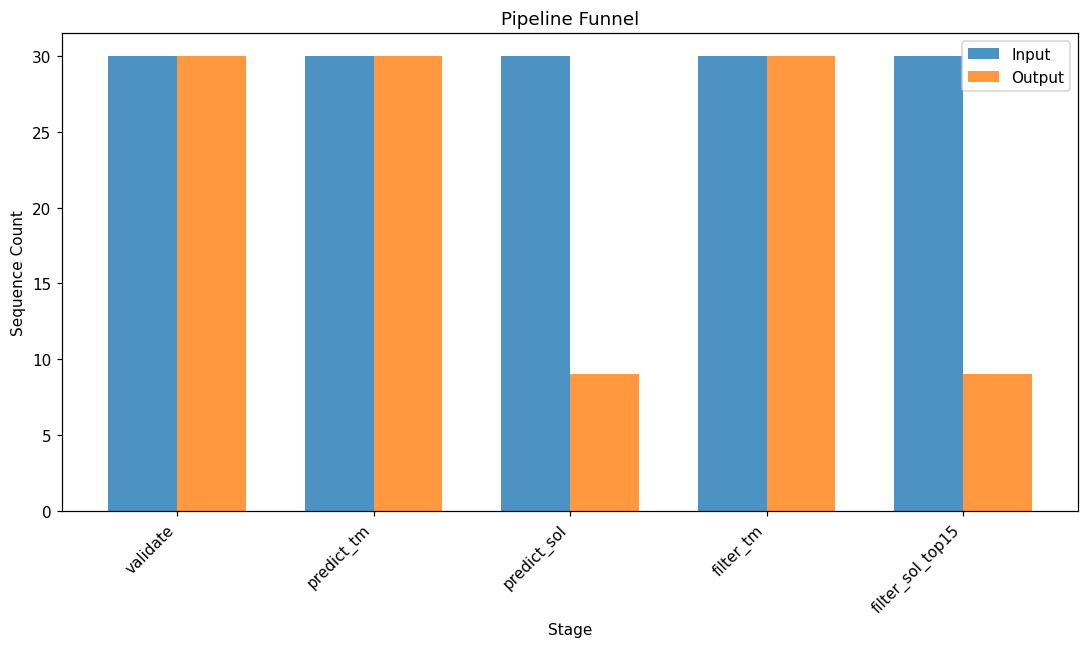

In [8]:
pipeline.plot("funnel")

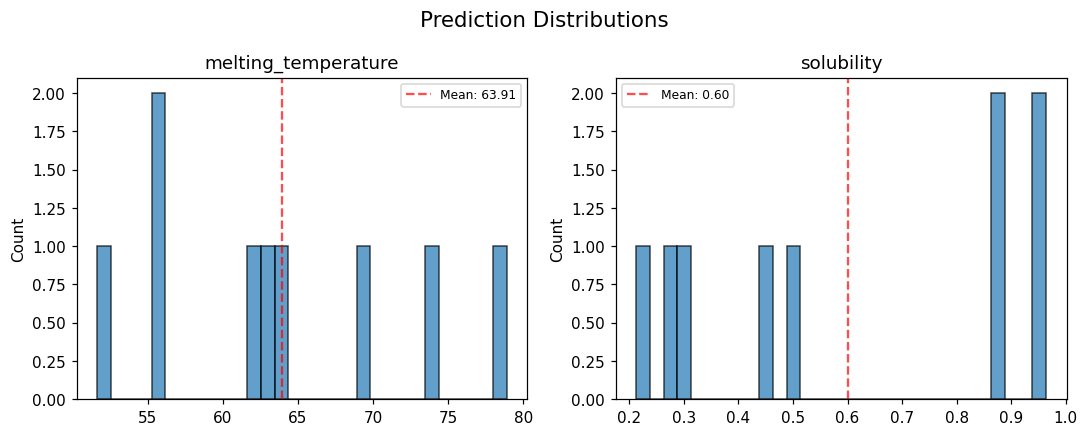

In [9]:
pipeline.plot("distributions")

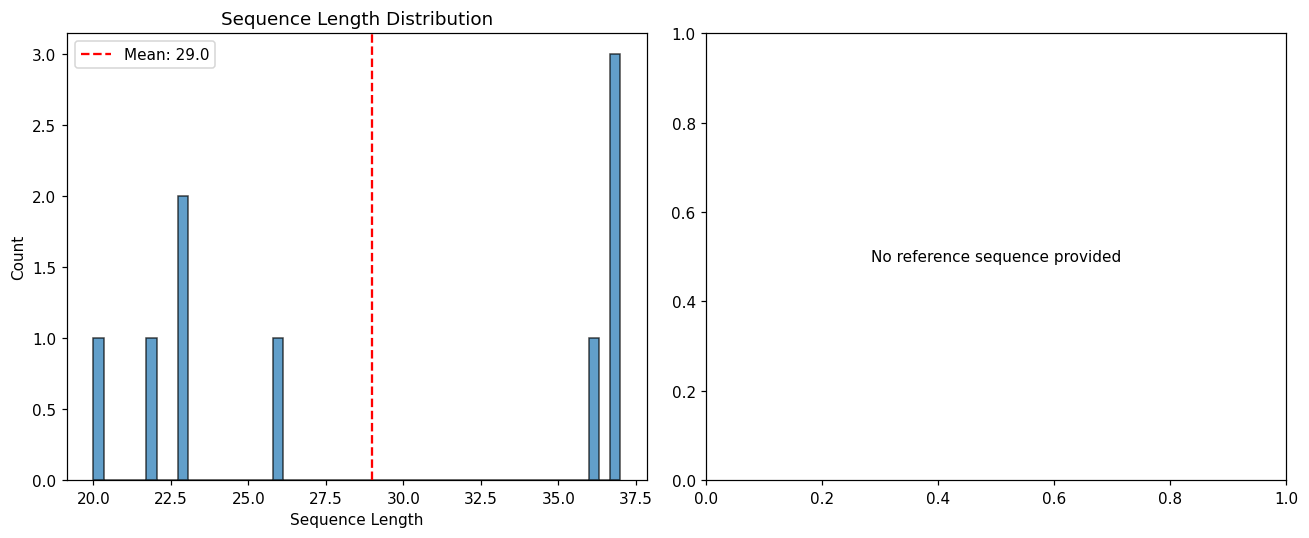

In [10]:
pipeline.plot("diversity")

## 5 — Scatter: Tm vs Solubility

SQL query to pivot predictions, then plot with filter survivors highlighted.

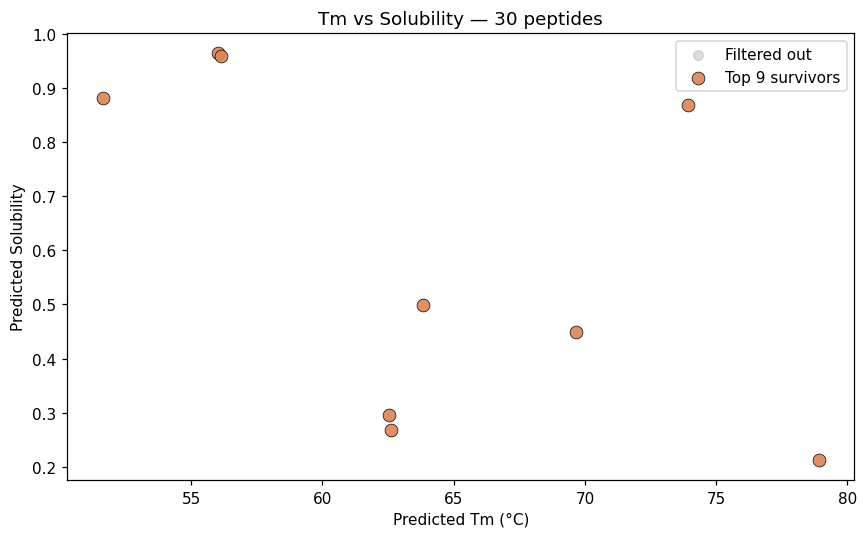

In [11]:
all_preds = pipeline.query("""
    SELECT
        s.sequence_id,
        s.sequence,
        MAX(CASE WHEN p.prediction_type = 'melting_temperature' THEN p.value END) AS tm,
        MAX(CASE WHEN p.prediction_type = 'solubility' THEN p.value END) AS solubility
    FROM sequences s
    JOIN predictions p ON s.sequence_id = p.sequence_id
    GROUP BY s.sequence_id, s.sequence
    HAVING tm IS NOT NULL AND solubility IS NOT NULL
""")

survivor_ids = set(df["sequence_id"].tolist())
is_survivor = all_preds["sequence_id"].isin(survivor_ids)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    all_preds.loc[~is_survivor, "tm"],
    all_preds.loc[~is_survivor, "solubility"],
    alpha=0.4, label="Filtered out", color="#aaaaaa", s=40,
)
ax.scatter(
    all_preds.loc[is_survivor, "tm"],
    all_preds.loc[is_survivor, "solubility"],
    alpha=0.9, label=f"Top {len(df)} survivors", color="#DD8452", s=70,
    edgecolors="black", linewidths=0.5,
)
ax.set_xlabel("Predicted Tm (\u00b0C)")
ax.set_ylabel("Predicted Solubility")
ax.set_title(f"Tm vs Solubility \u2014 {len(PEPTIDES)} peptides")
ax.legend()
plt.tight_layout()
plt.show()

## 6 — Resume: zero API calls on cached data

Re-run the same pipeline on the same DuckDB. All predictions are cached — no API calls needed.

In [12]:
pipeline2 = DataPipeline(
    sequences=PEPTIDES,
    datastore=ds,
    run_id="demo_v2",
    output_dir=str(OUTPUT_DIR),
    verbose=True,
)

pipeline2.add_filter(ValidAminoAcidFilter(), stage_name="validate")
pipeline2.add_prediction(
    "temberture-regression", action="predict",
    extractions="prediction", columns="melting_temperature",
    stage_name="predict_tm", depends_on=["validate"], batch_size=16,
)
pipeline2.add_prediction(
    "soluprot", action="predict",
    extractions="soluble", columns="solubility",
    stage_name="predict_sol", depends_on=["validate"], batch_size=16,
)
pipeline2.add_filter(
    ThresholdFilter("melting_temperature", min_value=40.0),
    stage_name="filter_tm", depends_on=["predict_tm", "predict_sol"],
)
pipeline2.add_filter(
    RankingFilter("solubility", n=15, ascending=False),
    stage_name="filter_sol_top15",
)

pipeline2.run()

print("\nCached run complete!")
pipeline2.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('predict_tm', depends_on=['validate'])
Added stage: PredictionStage('predict_sol', depends_on=['validate'])
Added stage: FilterStage('filter_tm', depends_on=['predict_tm', 'predict_sol'])
Added stage: FilterStage('filter_sol_top15', depends_on=['filter_tm'])

############################################################
# Pipeline: DataPipeline
# Run ID: demo_v2
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: predict_tm, predict_sol (parallel)
  Level 3: filter_tm
  Level 4: filter_sol_top15

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30

StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Executing 2 stages in parallel...

Stage: predict_tm
Input: 30 sequences
Depends on: valid

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_70843/2114644676.py:29: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  pipeline2.run()


  soluprot:   0%|          | 0/2 [00:00<?, ?batch/s]

  Completed: 21 sequences in 2 batches (max 5 concurrent)

StageResult(predict_sol: in=30, out=9, cached=9, computed=21, filtered=21, time=2.5s)

Stage: filter_tm
Input: 30 sequences
Depends on: predict_tm, predict_sol
  Applying filter: ThresholdFilter(column='melting_temperature', min=40.0)
  Filtered out: 0/30
  Remaining: 30

StageResult(filter_tm: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Stage: filter_sol_top15
Input: 30 sequences
Depends on: filter_tm
  Applying filter: RankingFilter(column='solubility', n=15, method='top')
  Filtered out: 21/30
  Remaining: 9

StageResult(filter_sol_top15: in=30, out=9, cached=0, computed=0, filtered=21, time=0.0s)

############################################################
# Pipeline completed in 2.6s
# Final sequences: 9
############################################################


Cached run complete!


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,predict_tm,30,30,0,30,0,0.0
2,predict_sol,30,9,21,9,21,2.5
3,filter_tm,30,30,0,0,0,0.0
4,filter_sol_top15,30,9,21,0,0,0.0


## 7 — Clustering: ESM2 embeddings \u2192 K-means \u2192 PCA

Embed with ESM2-8m, cluster into 3 groups, visualize with PCA.

In [13]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cluster_dir = OUTPUT_DIR / "cluster"
cluster_dir.mkdir(parents=True, exist_ok=True)
cluster_ds = DuckDBDataStore(cluster_dir / "pipeline.duckdb")

cp = DataPipeline(
    sequences=PEPTIDES,
    datastore=cluster_ds,
    run_id="cluster_v1",
    output_dir=str(cluster_dir),
    verbose=True,
)

cp.add_filter(ValidAminoAcidFilter(), stage_name="validate")

cp.add_prediction(
    "esm2-8m",
    action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed",
    depends_on=["validate"],
    batch_size=8,
    max_concurrent=4,
)

cp.add_clustering(
    method="kmeans",
    n_clusters=3,
    similarity_metric="embedding",
    embedding_model="esm2-8m",
    stage_name="cluster_k3",
    depends_on=["embed"],
)

cp.run()

cluster_df = cp.get_final_data()
print(f"\n{len(cluster_df)} sequences clustered")
cp.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('embed', depends_on=['validate'])
Added stage: ClusteringStage('cluster_k3', depends_on=['embed'])

############################################################
# Pipeline: DataPipeline
# Run ID: cluster_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 3 level(s)
  Level 1: validate
  Level 2: embed
  Level 3: cluster_k3

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30

StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Stage: embed
Input: 30 sequences
Depends on: validate
  Cached: 0/30
  To compute: 30
  Calling esm2-8m.encode...


/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_70843/1703777465.py:37: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  cp.run()


  esm2-8m:   0%|          | 0/4 [00:00<?, ?batch/s]

  Completed: 30 sequences in 4 batches (max 4 concurrent)

StageResult(embed: in=30, out=30, cached=0, computed=30, filtered=0, time=1.4s)

Stage: cluster_k3
Input: 30 sequences
Depends on: embed
  Clustering 30 sequences using kmeans...
  Loading embeddings from esm2-8m...
  Found 3 clusters
  Silhouette score: 0.246

StageResult(cluster_k3: in=30, out=30, cached=0, computed=30, filtered=0, time=0.1s)

############################################################
# Pipeline completed in 1.6s
# Final sequences: 30
############################################################


30 sequences clustered


,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,30,30,0,0,0,0.0
1,embed,30,30,0,0,30,1.4
2,cluster_k3,30,30,0,0,30,0.1


Cluster sizes:
 cluster_id  n_sequences
          0            5
          1           12
          2           13

Silhouette score: 0.246


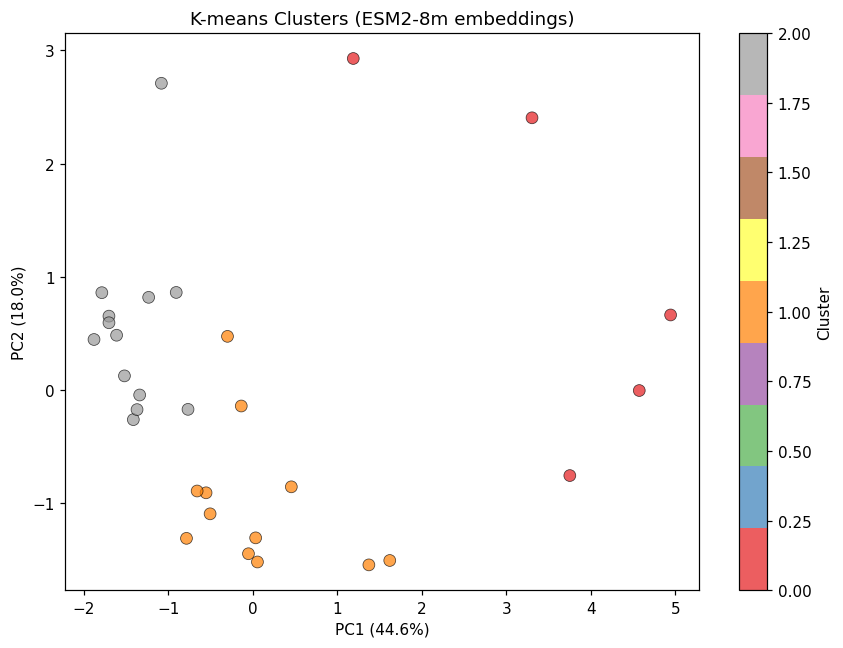

In [14]:
# Cluster sizes
cluster_sizes = cp.query("""
    SELECT CAST(p.value AS INTEGER) AS cluster_id, COUNT(*) AS n_sequences
    FROM predictions p
    WHERE p.prediction_type = 'cluster_k3'
    GROUP BY cluster_id
    ORDER BY cluster_id
""")
print("Cluster sizes:")
print(cluster_sizes.to_string(index=False))

# Get embeddings + labels for PCA
seq_ids = cluster_df["sequence_id"].tolist()
emb_map = cluster_ds.get_embeddings_bulk(seq_ids, model_name="esm2-8m")
ordered_ids = [sid for sid in seq_ids if sid in emb_map]
mat = np.stack([emb_map[sid] for sid in ordered_ids])

# Get cluster labels
label_df = cluster_ds.conn.execute("""
    SELECT sequence_id, CAST(value AS INTEGER) AS cluster_id
    FROM predictions WHERE prediction_type = 'cluster_k3'
""").df()
label_map = dict(zip(label_df["sequence_id"], label_df["cluster_id"]))
labels = np.array([label_map.get(sid, -1) for sid in ordered_ids])

# Silhouette score
valid = labels >= 0
if valid.sum() >= 3 and len(set(labels[valid])) >= 2:
    sil = silhouette_score(mat[valid], labels[valid])
    print(f"\nSilhouette score: {sil:.3f}")

# PCA plot
pca = PCA(n_components=2)
coords = pca.fit_transform(mat)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=labels, cmap="Set1", alpha=0.7, s=60,
    edgecolors="black", linewidth=0.5,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("K-means Clusters (ESM2-8m embeddings)")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

## 8 — Diversity sampling

Select maximally diverse representatives from the clustered sequences.

Added stage: FilterStage('validate')
Added stage: PredictionStage('embed', depends_on=['validate'])
Added stage: FilterStage('diversity_select', depends_on=['embed'])

############################################################
# Pipeline: DataPipeline
# Run ID: diversity_v1
# Initial sequences: 30
# Streaming: ENABLED
############################################################

Execution plan: 3 level(s)
  Level 1: validate
  Level 2: embed
  Level 3: diversity_select

Stage: validate
Input: 30 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/30
  Remaining: 30

StageResult(validate: in=30, out=30, cached=0, computed=0, filtered=0, time=0.0s)

Stage: embed
Input: 30 sequences
Depends on: validate
  Cached: 30/30
  To compute: 0

StageResult(embed: in=30, out=30, cached=30, computed=0, filtered=0, time=0.0s)

Stage: diversity_select
Input: 30 sequences
Depends on: embed
  Applying filter: DiversitySamplingFilter(n=15, method='random

/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_70843/2602056113.py:25: RuntimeWarning: pipeline.run() called from inside a running event loop (e.g. Jupyter). Use 'await pipeline.run_async()' instead for proper async execution. Attempting synchronous execution via nest_asyncio if available.
  dp.run()


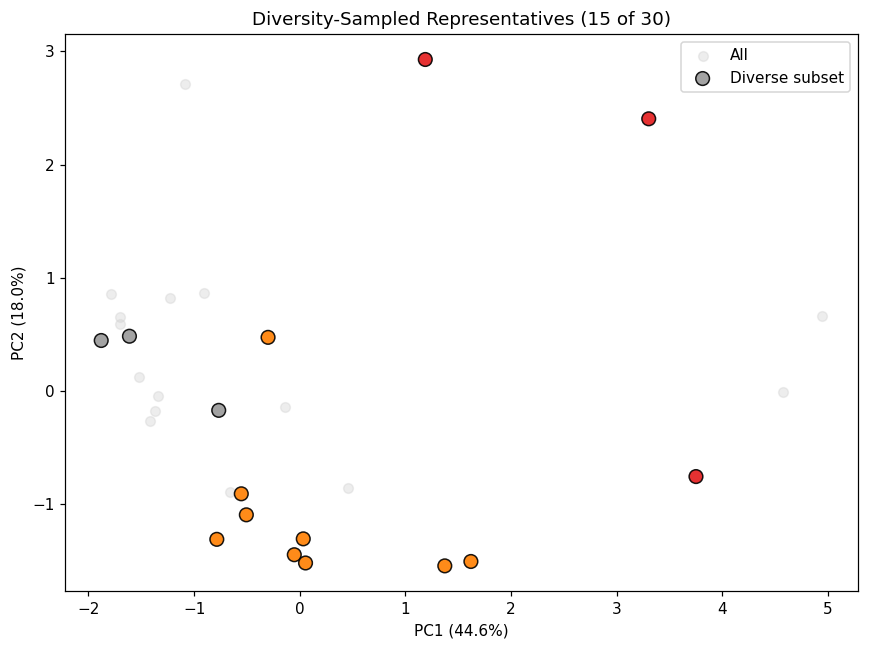

In [15]:
dp = DataPipeline(
    sequences=PEPTIDES,
    datastore=cluster_ds,  # reuse same DB — embeddings are cached
    run_id="diversity_v1",
    output_dir=str(cluster_dir),
    verbose=True,
)

dp.add_filter(ValidAminoAcidFilter(), stage_name="validate")

dp.add_prediction(
    "esm2-8m",
    action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed",
    depends_on=["validate"],
    batch_size=8,
)

dp.add_filter(
    DiversitySamplingFilter(n_samples=15, method="random"),
    stage_name="diversity_select",
)

dp.run()

diverse_df = dp.get_final_data()
diverse_ids = set(diverse_df["sequence_id"].tolist())
print(f"\nSelected {len(diverse_df)} diverse representatives from {len(PEPTIDES)}")

# Highlight on PCA
is_diverse = np.array([sid in diverse_ids for sid in ordered_ids])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    coords[~is_diverse, 0], coords[~is_diverse, 1],
    c="lightgray", alpha=0.4, s=40, label="All",
)
ax.scatter(
    coords[is_diverse, 0], coords[is_diverse, 1],
    c=labels[is_diverse], cmap="Set1", alpha=0.9, s=80,
    edgecolors="black", linewidth=1, label="Diverse subset",
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"Diversity-Sampled Representatives ({len(diverse_df)} of {len(PEPTIDES)})")
ax.legend()
plt.tight_layout()
plt.show()

## 9 — Export results

In [16]:
# CSV export
csv_path = OUTPUT_DIR / "demo_results.csv"
save_cols = [c for c in df.columns if c != "hash"]
df[save_cols].to_csv(csv_path, index=False)
print(f"CSV: {csv_path} ({len(df)} rows)")

# Full DuckDB export
full_export = ds.export_to_dataframe(include_sequences=True)
print(f"\nFull DuckDB export: {full_export.shape[0]} rows \u00d7 {full_export.shape[1]} cols")
print(f"Columns: {full_export.columns.tolist()}")
full_export.head()

CSV: outputs/notebook_demo/demo_results.csv (9 rows)

Full DuckDB export: 30 rows × 6 cols
Columns: ['sequence_id', 'sequence', 'length', 'hash', 'melting_temperature', 'solubility']


,sequence_id,sequence,length,hash,melting_temperature,solubility
0,2,GIGKFLHSAGKFGKAFVGEIMKS,23,2272bcf58012e271,62.593925,0.2674
1,6,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,37,2812049e6fed6cf1,73.924812,0.8687
2,12,GIGAVLKVLTTGLPALISWIKRKRQQ,26,16992c17ef86f261,51.632015,0.8815
3,18,KWKWKWKWKW,10,10e3164088f6fa65,55.864277,NaN
4,21,RRWQWR,6,4108b656ede327c5,53.030869,NaN


## 10 — Cleanup

In [17]:
ds.close()
cluster_ds.close()
print("Datastores closed.")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print(f"Re-run with the same output dir to hit the cache (zero API calls).")

Datastores closed.

All outputs saved to: outputs/notebook_demo
Re-run with the same output dir to hit the cache (zero API calls).


## Summary

| Feature | Section |
|---|---|
| Multi-model predictions + filtering | \u00a72 |
| summary(), explore(), stats(), query() | \u00a73 |
| plot() \u2014 funnel, distributions, diversity | \u00a74 |
| Scatter: Tm vs Solubility | \u00a75 |
| Resume (zero API calls on cached data) | \u00a76 |
| Clustering \u2014 ESM2 + K-means + PCA | \u00a77 |
| Diversity sampling + visualization | \u00a78 |
| Export \u2014 CSV, DuckDB DataFrame | \u00a79 |